# 03 — CNN Model: Mel-Spectrogram + Convolutional Neural Network (A100 Optimized)

Train a CNN on log-mel spectrograms extracted from UrbanSound8K.

**Pipeline**: Audio clips → mel-spectrogram (128×173) → CNN (4 conv blocks) → 10-class classification.

**Target**: Improve on baseline RF (72.64%) and SVM (73.00%) test accuracy from notebook 02.

**Evaluation**: Folds 1–8 train · Fold 9 val (model selection) · Fold 10 test (reported once).

**A100 Optimizations**:
- Pre-computed mel-spectrograms (joblib parallel) — eliminates 212,370 redundant librosa calls
- Automatic Mixed Precision (AMP) — 2-3× speedup on Tensor Cores
- `torch.compile` — kernel fusion for additional 10-30% speedup
- Batch size 256, 4 DataLoader workers with `persistent_workers`
- CosineAnnealingLR scheduler

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/NYC-cafe-study-friendliness')

!pip install torch torchaudio librosa soundfile scikit-learn -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchaudio.transforms as T
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed

from src.dataset import get_fold_data, get_default_split, CLASS_NAMES, NUM_CLASSES
from src.audio_features import extract_mel_spectrogram

%matplotlib inline

PROJECT_ROOT = '/content/drive/MyDrive/NYC-cafe-study-friendliness'

# Feature constants — must match src/audio_features.py defaults
SR          = 22050
N_MELS      = 128
HOP_LENGTH  = 512
FIXED_T     = 173   # ceil(88200 / 512) = 173 frames for a 4s clip at 22050 Hz

# Training hyperparameters — tuned for A100 (40 GB VRAM)
BATCH_SIZE  = 256   # A100 can easily handle this; model is ~400K params
EPOCHS      = 30
LR          = 1e-3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Enable cuDNN autotuner — finds fastest convolution algorithms for fixed input sizes
torch.backends.cudnn.benchmark = True

Using device: cuda


## 1. Load Data

In [13]:
# Copy dataset to local disk for faster I/O during training
!cp -r "/content/drive/MyDrive/NYC-cafe-study-friendliness/data/UrbanSound8K" "/content/UrbanSound8K"
DATA_DIR = '/content/UrbanSound8K'

split = get_default_split()
print(f"Train folds: {split['train']}")
print(f"Val folds:   {split['val']}")
print(f"Test folds:  {split['test']}")

print('\nLoading training data...')
train_audios, y_train, _ = get_fold_data(DATA_DIR, split['train'], sr=SR)
print(f'  {len(train_audios)} clips')

print('Loading validation data...')
val_audios, y_val, _ = get_fold_data(DATA_DIR, split['val'], sr=SR)
print(f'  {len(val_audios)} clips')

print('Loading test data...')
test_audios, y_test, _ = get_fold_data(DATA_DIR, split['test'], sr=SR)
print(f'  {len(test_audios)} clips')

Train folds: [1, 2, 3, 4, 5, 6, 7, 8]
Val folds:   [9]
Test folds:  [10]

Loading training data...
  7079 clips
Loading validation data...
  816 clips
Loading test data...
  837 clips


## 2. Pre-compute Mel-Spectrograms and Build Dataset

**Key optimization**: Extract all mel-spectrograms ONCE before training using parallel
workers (joblib), then store them as numpy arrays. This eliminates the single-threaded
librosa bottleneck from `__getitem__` — the original design called `extract_mel_spectrogram()`
on every batch access, resulting in 7079 clips × 30 epochs = 212,370 redundant librosa calls.

With pre-computation, those 212,370 calls become 8,732 calls (once per clip), parallelized
across all available CPU cores. Storage cost: ~750 MB for all spectrograms at (128, 173) float32,
well within A100 Colab's 80 GB system RAM.

`PrecomputedDataset.__getitem__` is now a simple array index (zero CPU cost per batch).
SpecAugment (frequency + time masking) is still applied on-the-fly during training.

In [14]:
# ── Pre-compute mel-spectrograms in parallel ─────────────────────────────
def _extract_and_pad(y, sr, n_mels, hop_length, fixed_t):
    """Extract one mel-spectrogram, pad/truncate to fixed_t frames."""
    mel = extract_mel_spectrogram(y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    if mel.shape[1] < fixed_t:
        mel = np.pad(mel, ((0, 0), (0, fixed_t - mel.shape[1])),
                     mode='constant', constant_values=mel.min())
    else:
        mel = mel[:, :fixed_t]
    return mel   # (128, 173) float64


def precompute_spectrograms(audios, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH,
                            fixed_t=FIXED_T, n_jobs=-1):
    """Pre-compute all mel-spectrograms in parallel using joblib.

    Returns:
        np.ndarray of shape (N, 128, 173) float32
    """
    print(f'  Pre-computing {len(audios)} spectrograms (n_jobs={n_jobs})...')
    mels = Parallel(n_jobs=n_jobs, backend='loky', verbose=1)(
        delayed(_extract_and_pad)(y, sr, n_mels, hop_length, fixed_t)
        for y in audios
    )
    return np.array(mels, dtype=np.float32)


print('Pre-computing mel-spectrograms for all splits...')
import time
t0 = time.time()

train_mels = precompute_spectrograms(train_audios)
val_mels   = precompute_spectrograms(val_audios)
test_mels  = precompute_spectrograms(test_audios)

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s — {len(train_mels) + len(val_mels) + len(test_mels)} '
      f'spectrograms pre-computed.')
print(f'Train: {train_mels.shape}, Val: {val_mels.shape}, Test: {test_mels.shape}')
mem_mb = (train_mels.nbytes + val_mels.nbytes + test_mels.nbytes) / 1e6
print(f'Total memory: {mem_mb:.1f} MB')

# Free raw audio — no longer needed
del train_audios, val_audios, test_audios


# ── Simplified Dataset — indexes pre-computed tensors ─────────────────────
class PrecomputedDataset(Dataset):
    """Dataset backed by pre-computed mel-spectrograms (zero CPU cost per batch)."""

    def __init__(self, mels, labels, augment=False):
        """
        Args:
            mels: np.ndarray of shape (N, 128, 173) float32
            labels: np.ndarray of class IDs
            augment: If True, apply SpecAugment (freq + time masking)
        """
        self.mels    = mels                          # numpy array
        self.labels  = torch.LongTensor(labels)
        self.augment = augment

        # SpecAugment transforms — applied only when augment=True
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=25)

    def __len__(self):
        return len(self.mels)

    def __getitem__(self, idx):
        # Direct array index → [1, 128, 173] tensor (no librosa call)
        mel_tensor = torch.from_numpy(self.mels[idx]).unsqueeze(0)  # [1, 128, 173]

        if self.augment:
            mel_tensor = self.freq_mask(mel_tensor)
            mel_tensor = self.time_mask(mel_tensor)

        return mel_tensor, self.labels[idx]

Pre-computing mel-spectrograms for all splits...
  Pre-computing 7079 spectrograms (n_jobs=-1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 664 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 2664 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 5464 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 7079 out of 7079 | elapsed:   14.8s finished


  Pre-computing 816 spectrograms (n_jobs=-1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 816 out of 816 | elapsed:    1.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.1s


  Pre-computing 837 spectrograms (n_jobs=-1)...

Done in 17.7s — 8732 spectrograms pre-computed.
Train: (7079, 128, 173), Val: (816, 128, 173), Test: (837, 128, 173)
Total memory: 773.4 MB


[Parallel(n_jobs=-1)]: Done 785 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 837 out of 837 | elapsed:    1.3s finished


In [15]:
train_ds = PrecomputedDataset(train_mels, y_train, augment=True)
val_ds   = PrecomputedDataset(val_mels,   y_val,   augment=False)
test_ds  = PrecomputedDataset(test_mels,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

# Verify shapes
x_sample, y_sample = next(iter(train_loader))
print(f'Input batch shape: {x_sample.shape}')   # expect [256, 1, 128, 173]
print(f'Label batch shape: {y_sample.shape}')    # expect [256]

Input batch shape: torch.Size([256, 1, 128, 173])
Label batch shape: torch.Size([256])


## 3. CNN Architecture

Four conv blocks (Conv2d → BatchNorm2d → ReLU → MaxPool2d), each halving both frequency
and time dimensions. `AdaptiveAvgPool2d(1,1)` collapses remaining spatial dims before
the classifier head.

```
Input [B, 1, 128, 173]
  Block 1  → [B,  32,  64,  86]
  Block 2  → [B,  64,  32,  43]
  Block 3  → [B, 128,  16,  21]
  Block 4  → [B, 256,   8,  10]
  AvgPool  → [B, 256,   1,   1]
  Flatten  → [B, 256]
  Dropout(0.3) → Linear(256, 10)
```

In [16]:
class UrbanSoundCNN(nn.Module):
    """4-block CNN for 10-class urban sound classification from mel-spectrograms."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(1,   32),
            conv_block(32,  64),
            conv_block(64,  128),
            conv_block(128, 256),
        )
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model = UrbanSoundCNN().to(DEVICE)

# torch.compile fuses ops and generates optimized kernels — significant speedup on A100
if hasattr(torch, 'compile'):
    print('Compiling model with torch.compile...')
    model = torch.compile(model)
    print('Done.')
else:
    print('torch.compile not available (requires PyTorch >= 2.0); skipping.')

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

Compiling model with torch.compile...
Done.
OptimizedModule(
  (_orig_mod): UrbanSoundCNN(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (1): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

## 4. Training

Adam optimizer, CrossEntropyLoss, 30 epochs with CosineAnnealingLR scheduler.
Automatic Mixed Precision (AMP) uses float16 on A100 Tensor Cores for ~2-3× throughput.

Best model (by validation accuracy) is saved to `models/cnn_best.pt`.
An asterisk `*` marks epochs where the checkpoint is updated.

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# AMP: autocast for forward pass, GradScaler for backward pass
use_amp = (DEVICE.type == 'cuda')
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

models_dir = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(models_dir, exist_ok=True)
best_model_path = os.path.join(models_dir, 'cnn_best.pt')

import time
train_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)  # slightly faster than zero_grad()

        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * X_batch.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(y_batch).sum().item()
        total    += y_batch.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── Validate ────────────────────────────────────────────────────────────
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad(), torch.amp.autocast('cuda', enabled=use_amp):
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            _, preds = outputs.max(1)
            correct  += preds.eq(y_batch).sum().item()
            total    += y_batch.size(0)

    val_loss = running_loss / total
    val_acc  = correct / total

    # Step scheduler (after validation, so we log the LR used for this epoch)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Save best checkpoint
    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Save the underlying model state_dict (unwrap torch.compile if needed)
        torch.save(model.state_dict(), best_model_path)
        marker = ' *'

    epoch_time = time.time() - epoch_start
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | '
          f'LR: {current_lr:.2e} | {epoch_time:.1f}s{marker}')

total_time = time.time() - train_start
print(f'\nTotal training time: {total_time:.1f}s ({total_time/60:.1f} min)')
print(f'Best val accuracy: {best_val_acc:.4f}')
print(f'Checkpoint saved to {best_model_path}')

Epoch  1/30 | Train Loss: 1.7317  Acc: 0.3525 | Val Loss: 1.6332  Acc: 0.4363 | LR: 1.00e-03 | 56.9s *
Epoch  2/30 | Train Loss: 1.3404  Acc: 0.5186 | Val Loss: 1.6550  Acc: 0.3713 | LR: 9.97e-04 | 10.3s
Epoch  3/30 | Train Loss: 1.1767  Acc: 0.5898 | Val Loss: 1.1973  Acc: 0.5870 | LR: 9.89e-04 | 1.1s *
Epoch  4/30 | Train Loss: 1.0305  Acc: 0.6533 | Val Loss: 1.1719  Acc: 0.5233 | LR: 9.76e-04 | 1.1s
Epoch  5/30 | Train Loss: 0.9220  Acc: 0.6968 | Val Loss: 1.1498  Acc: 0.6287 | LR: 9.57e-04 | 1.1s *
Epoch  6/30 | Train Loss: 0.8481  Acc: 0.7235 | Val Loss: 1.1077  Acc: 0.5944 | LR: 9.33e-04 | 1.0s
Epoch  7/30 | Train Loss: 0.7894  Acc: 0.7471 | Val Loss: 1.1030  Acc: 0.6691 | LR: 9.05e-04 | 1.1s *
Epoch  8/30 | Train Loss: 0.7284  Acc: 0.7728 | Val Loss: 1.2350  Acc: 0.6422 | LR: 8.72e-04 | 1.1s
Epoch  9/30 | Train Loss: 0.6793  Acc: 0.7891 | Val Loss: 1.3462  Acc: 0.5355 | LR: 8.35e-04 | 1.0s
Epoch 10/30 | Train Loss: 0.6409  Acc: 0.7955 | Val Loss: 0.8915  Acc: 0.7635 | LR: 7.94e-

## 5. Training Curves

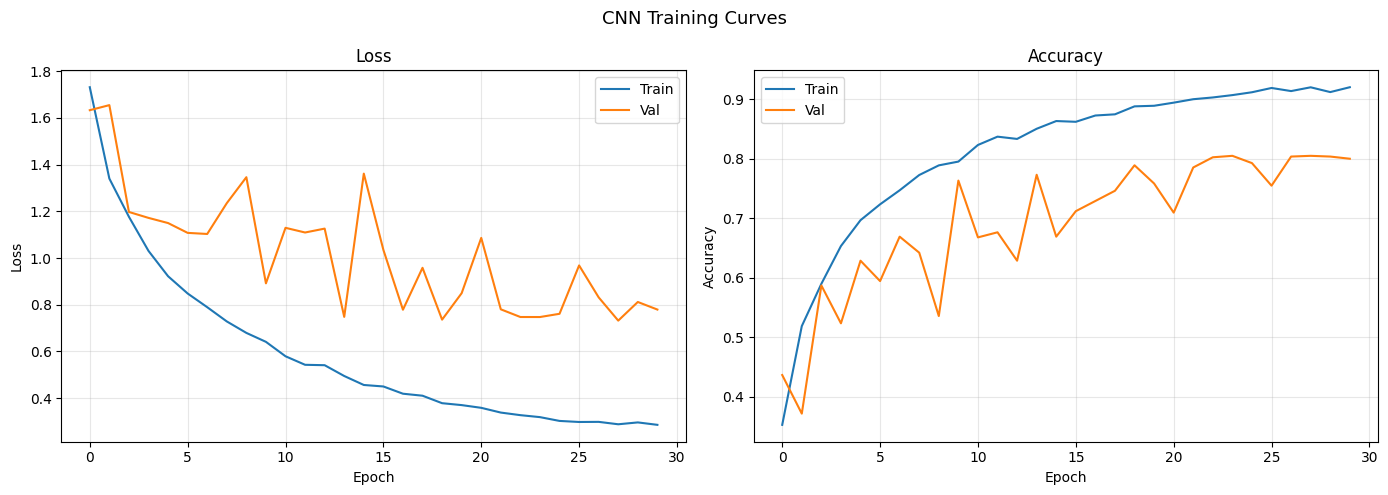

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Training Curves', fontsize=13)
plt.tight_layout()

results_dir = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, 'cnn_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Test Evaluation

Load the best checkpoint (saved during training on validation accuracy) and evaluate
on the held-out test fold (fold 10). This fold was never used for training or model selection.

In [19]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad(), torch.amp.autocast('cuda', enabled=use_amp):
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(DEVICE, non_blocking=True))
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
cnn_acc    = accuracy_score(all_labels, all_preds)

print(f'CNN Test Accuracy: {cnn_acc:.4f}\n')

target_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
print(classification_report(all_labels, all_preds,
                             labels=list(range(NUM_CLASSES)),
                             target_names=target_names,
                             zero_division=0))

CNN Test Accuracy: 0.8339

                  precision    recall  f1-score   support

 air_conditioner       0.88      0.69      0.78       100
        car_horn       0.83      0.91      0.87        33
children_playing       0.70      0.89      0.78       100
        dog_bark       0.84      0.71      0.77       100
        drilling       0.84      0.81      0.82       100
   engine_idling       0.93      0.90      0.92        93
        gun_shot       0.97      1.00      0.98        32
      jackhammer       0.85      0.97      0.91        96
           siren       0.81      0.76      0.78        83
    street_music       0.83      0.86      0.84       100

        accuracy                           0.83       837
       macro avg       0.85      0.85      0.85       837
    weighted avg       0.84      0.83      0.83       837



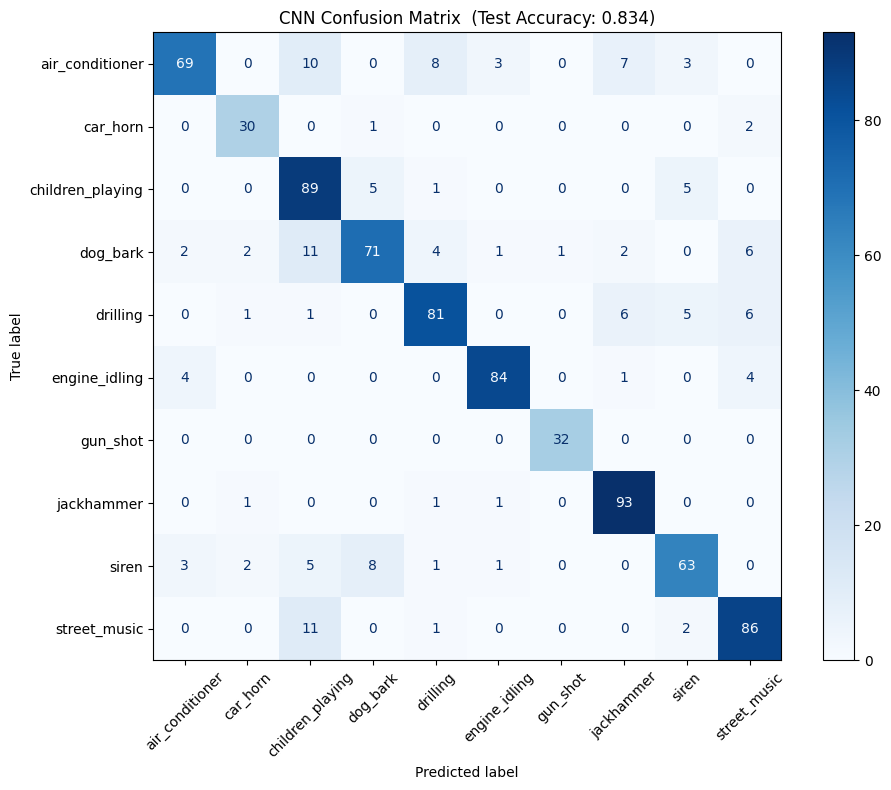

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    display_labels=target_names,
    ax=ax, xticks_rotation=45, cmap='Blues'
)
ax.set_title(f'CNN Confusion Matrix  (Test Accuracy: {cnn_acc:.3f})')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'cnn_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison

In [21]:
comparison = pd.DataFrame({
    'Model':         ['Random Forest', 'SVM (RBF)',            'CNN (this notebook)'],
    'Features':      ['MFCC (240-dim)', 'MFCC (240-dim)',      'Log-Mel (128×173)'],
    'Test Accuracy': [0.7264,           0.7300,                cnn_acc],
})
comparison['Test Accuracy'] = comparison['Test Accuracy'].map('{:.4f}'.format)
display(comparison)

,Model,Features,Test Accuracy
0,Random Forest,MFCC (240-dim),0.7264
1,SVM (RBF),MFCC (240-dim),0.7300
2,CNN (this notebook),Log-Mel (128×173),0.8339
